In [ ]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve


In [ ]:
df=pd.read_csv('/content/data.csv')
# Drop unnecessary columns
df = df.drop(columns=["id"])  # Remove 'id' column

# Encode target: M = 0, B = 1
df["diagnosis"] = df["diagnosis"].map({"M": 0, "B": 1})
# Check & remove rows with all NaNs (edge case)
df = df.dropna(how="all")

# Fill missing values with column means (only for numeric columns)
df = df.fillna(df.mean(numeric_only=True))

# Confirm no NaNs remain
print(df.isnull().sum().sum(), "NaN values remaining")



569 NaN values remaining


In [ ]:
# 3. Split Features and Target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [ ]:
# 4. Train-Test Split and Standardization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# 6. Evaluate the Model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_proba = model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC Score: 0.99737962659679


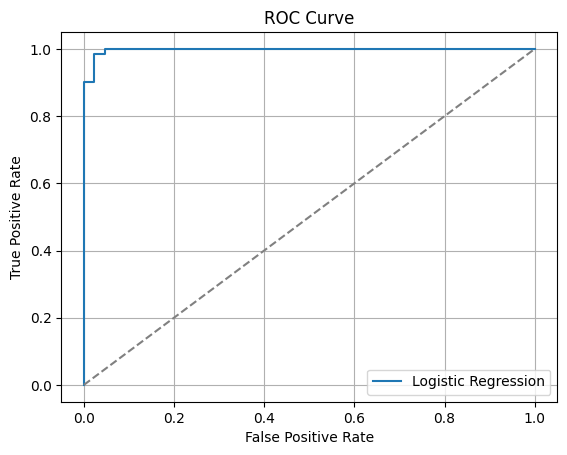

In [ ]:
# 7. ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
#Tune threshold and explain sigmoid
from sklearn.metrics import confusion_matrix

y_probs = model.predict_proba(X_test_scaled)[:, 1]  # get probabilities
threshold = 0.3  # you can try 0.3, 0.5, 0.7 etc.
y_custom = (y_probs >= threshold).astype(int)

print(confusion_matrix(y_test, y_custom))


[[41  2]
 [ 0 71]]
